<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# Chapter 5: 在无标签数据上进行预训练

In [44]:
from importlib.metadata import version

pkgs = ["matplotlib", 
        "numpy", 
        "tiktoken", 
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.8
numpy version: 2.2.6
tiktoken version: 0.12.0
torch version: 2.10.0
tensorflow version: 2.20.0


本章中，我们将实现训练循环和用于基本模型评估的代码，以预训练 LLM 模型。   
在本章末尾，我们还将来自 OpenAI 的公开预训练权重加载到我们的模型中。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/01.webp" width=800px>

本章涵盖的主题如下所示。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/02.webp" width=800px>

## 5.1 评估生成式文本模型

- 本节首先简要回顾一下如何使用上一章的代码初始化 GPT 模型
- 然后，我们讨论LLM的基本评估指标
- 最后，在本节中，我们将这些评估指标应用于训练集和验证集

### 5.1.1 使用GPT来生成文本

我们使用上一章的代码初始化一个 GPT 模型。

In [45]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

- 我们上面使用的是 dropout 值为 0.1，但现在训练 LLM 时不使用 dropout 也比较常见。
- 现代线性模型（LLM）也不在查询矩阵、键矩阵和值矩阵的 `nn.Linear` 层中使用偏置向量（与早期的 GPT 模型不同），这是通过将 `"qkv_bias": False` 设置为 `False` 来实现的
- 为了降低模型训练所需的计算资源，我们将上下文长度（`context_length`）减少到仅 256 个 token，而原始的 1.24 亿参数 GPT-2 模型使用了 1024 个 token
  - 这样一来，更多的读者就能在他们的笔记本电脑上跟随并运行代码示例了
  - 不过，您可以将 `context_length` 增加到 1024 个 token（这不需要任何代码更改）
  - 稍后我们将从预训练权重中加载一个 `context_length` 为 1024 的模型

- 接下来，我们使用上一章中的 `generate_text_simple` 函数来生成文本。
- 此外，我们还定义了两个便捷函数 `text_to_token_ids` 和 `token_ids_to_text`，用于在本章中实现标记表示和文本表示之间的转换。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/03.webp" width=900px>

In [46]:
import tiktoken
from previous_chapters import generate_text_simple

# Alternatively:
# from llms_from_scratch.ch04 import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


- 如上所示，该模型无法生成高质量的文本，因为它尚未经过训练
- 我们如何以数字形式衡量或捕捉“优质文本”的含义，以便在训练过程中进行跟踪？
- 下一小节将介绍用于计算生成输出损失指标的度量方法，我们可以利用这些指标来衡量训练进度。
- 接下来的章节将介绍如何微调LLM模型，并介绍衡量模型质量的其他方法

### 5.1.2 计算文本生成损失：交叉熵和困惑度

- 假设我们有一个 `inputs` 张量，其中包含 2 个训练样本（行）的 token ID。
- 与 `inputs` 相对应，`targets` 包含我们希望模型生成的期望标记 ID。
- 请注意，“目标”是“输入”向右移动一位后的值，正如我们在第二章实现数据加载器时解释的那样

In [47]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

- 将“输入”提供给模型，我们得到两个输入样本的logits向量，每个样本包含3个词元。
- 每个词元都是一个 50,257 维的向量，与词汇表的大小相对应。
- 应用softmax函数，我们可以将logits张量转换为包含概率得分的相同维度张量 

In [48]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


- 下图为了便于说明，仅使用了极少的词汇，概述了我们如何将概率分数转换回文本，这部分内容我们在上一章末尾已经讨论过。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/04.webp" width=900px>

- 如前一章所述，我们可以应用`argmax`函数将概率得分转换为预测的标记ID
- 上面的 softmax 函数为每个 token 生成了一个 50,257 维的向量；`argmax` 函数返回该向量中概率得分最高的位置，即给定 token 的预测 token ID。

- 由于我们有 2 个输入批次，每个批次包含 3 个标记，因此我们得到 2×3 个预测标记 ID:

In [49]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


- 如果我们解码这些词元，会发现它们与我们希望模型预测的词元（即目标词元）截然不同:

In [50]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


- 那是因为模型还没有经过训练
- 为了训练模型，我们需要知道它与正确预测（目标）之间的差距有多大

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/06.webp" width=900px>

- 与目标索引对应的词元概率如下:

In [51]:
# probas是归一化之后词库中所有词的每一个词的概率
# probas 的形状是 (batch_size, num_tokens, vocab_size) = (2, 3, 50257)
#  batch_size = 2 ：两段文本
#  num_tokens = 3 ：每段文本关注3个位置
#  vocab_size = 50257 ：GPT-2 的词汇表大小

# probas[text_idx, [0, 1, 2], targets[text_idx]] 这个索引操作：
#  text_idx：选择 batch 中的第几个样本（0或1）
#  [0, 1, 2]：选择第0、1、2三个 token 位置
#  targets[text_idx]：获取该文本对应的 目标 token ID

text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


- 我们希望最大化所有这些值，使它们接近概率 1
- 在数学优化中，最大化概率得分的对数比最大化概率得分本身更容易；这超出了本书的范围，但我录制了一个讲座，其中有更详细的讲解，点击此处查看: [L8.2 Logistic Regression Loss Function](https://www.youtube.com/watch?v=GxJe0DZvydM)

In [52]:
# 计算所有令牌概率的对数
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


- 接下来，我们计算平均对数概率:

In [53]:
# 计算每个令牌的平均概率
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


- 目标是通过优化模型权重，使平均对数概率尽可能大
- 由于使用了对数，最大可能值为 0，而我们目前距离 0 还很远

- 在深度学习中，我们通常不是最大化平均对数概率，而是遵循标准惯例来最小化平均对数概率的负值；在我们的例子中，不是最大化-10.7722使其接近0，在深度学习中，我们会最小化10.7722使其接近0。
- 负-10.7722的值，即10.7722，在深度学习中也被称为交叉熵损失

In [54]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


- PyTorch 已经实现了一个 `cross_entropy` 函数，用于执行上述步骤

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/07.webp" width=900px>

- 在应用 `cross_entropy` 函数之前，我们先来检查一下 logits 和 targets 的形状

In [55]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


- 对于 PyTorch 中的 `cross_entropy` 函数，我们希望通过在批次维度上合并这些张量来展平它们:

In [56]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


- 请注意，目标是token ID，它们也代表我们想要最大化的 logits 张量中的索引位置。
- PyTorch 中的 `cross_entropy` 函数会自动在内部对需要最大化的 logits 中的 token 索引应用 softmax 和对数概率计算 

In [57]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


- 与交叉熵损失相关的概念是LLM的困惑度
- 困惑度就是交叉熵损失的指数

In [58]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


- 困惑度通常被认为更容易解释，因为它可以理解为模型在每一步中不确定的有效词汇量（在上面的例子中，就是 48,725 个单词或标记）
- 换句话说，困惑度衡量的是模型预测的概率分布与数据集中词语的实际分布匹配程度
- 与损失函数类似，较低的困惑度表明模型预测结果更接近实际分布

### 5.1.3 计算训练集和验证集的损失

- 我们使用相对较小的数据集来训练 LLM（实际上，只有一个短篇故事）
- 原因如下:
  - 即使没有合适的GPU，您也可以在笔记本电脑上几分钟内运行这些代码示例
  - 训练完成得相对较快（只需几分钟而不是几周），这有利于教学目的
  - 我们使用的是公共领域的文本，将其包含在此 GitHub 仓库中不会侵犯任何使用权，也不会增加仓库大小


- 例如，Llama 2 7B 需要使用 A100 GPU 进行 184,320 个 GPU 小时的训练，才能处理 2 万亿个令牌
  - 截至撰写本文时，AWS 上 8 台 A100 云服务器的每小时成本约为 30 美元
  - 因此，通过粗略估算，训练这位LLM的费用为184,320 / 8 * \\$30 = \\$690,000
 
- 下面，我们使用与第二章相同的数据集

In [59]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

- 通过打印文本的前 99 个字符和后 99 个字符，快速检查文本是否加载成功

In [60]:
# First 99 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [61]:
# Last 99 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [62]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


- 这段文本只有 5145 个 token，对于训练 LLM 来说太短了，但再次强调，这是出于教学目的（我们稍后还会加载预训练权重）

- 接下来，我们将数据集划分为训练集和验证集，并使用第二章中的数据加载器来准备 LLM 训练所需的批次。
- 为了便于可视化，下图假设 `max_length=6`，但对于训练加载器，我们将 `max_length` 设置为 LLM 支持的上下文长度
- 为简洁起见，下图仅显示输入标记
    - 由于我们训练 LLM 来预测文本中的下一个词，因此目标词与输入词看起来相同，只是目标词的位置偏移了一个位置。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/09.webp" width=900px>

In [63]:
from previous_chapters import create_dataloader_v1
# Alternatively:
# from llms_from_scratch.ch02 import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [64]:
# 合理性检查：为了确保训练集和验证集中数据量大于模型的上下文窗口，避免出现训练/验证错误

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

- 我们使用相对较小的批次大小来降低计算资源需求，而且由于数据集本身就非常小
- 例如，Llama 2 7B 的训练批次大小为 1024

In [65]:
# 可选检查数据是否已正确加载
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- 另一个可选检查是确保token大小在预期范围内:

In [66]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [67]:
# 计算给定批次的交叉熵损失
def calc_loss_batch(input_batch, target_batch, model, device):
    # .to(device)能把计算转移到GPU
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    # ❓，为什么要flatten?
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

# 用于计算数据加载器中用户指定数量批次的总损失。
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # 取num_batches和len(data_loader)两者较小值以匹配data_loader中的总批次数量
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- 如果您的机器配备了支持 CUDA 的 GPU，LLM 将在 GPU 上进行训练，无需对代码进行任何更改。
- 通过“device”设置，我们确保数据加载到与 LLM 模型相同的设备上

In [68]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cuda device.
Training loss: 10.987583266364204
Validation loss: 10.98110580444336


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/10.webp" width=900px>

## 5.2 训练大语言模型

- 在本节中，我们最终实现了用于训练 LLM 的代码
- 我们专注于一个简单的训练函数（如果你对使用更先进的技术增强这个训练函数感兴趣，例如学习率预热、余弦退火和梯度裁剪，请参考[Appendix D](../../appendix-D/01_main-chapter-code))

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/11.webp" width=500px>

In [69]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 初始化列表以跟踪损失和所见的token
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # 开始主训练循环
    for epoch in range(num_epochs):
        model.train()  # 将模型设置为训练模式
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 重置上一批次迭代的损失梯度
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # 计算损失梯度
            optimizer.step() # 利用损失梯度更新模型权重
            tokens_seen += input_batch.numel()
            global_step += 1

            # 可选的评估步骤
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 每轮之后打印一个文本样本
        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    # 在评估阶段禁用dropout, 以产出稳定且可复现的结果
    model.eval()
    with torch.no_grad(): # 评估阶段叶会禁用梯度跟踪，因为这是不需要的，而且这样可以减少计算开销
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

# 运行一次推理，看看生成的效果
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    # 紧凑的打印格式
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

- 现在，让我们使用上面定义的训练函数来训练 LLM：

In [72]:
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

# Adam优化器是训练深度神经网络的一种常见选择。然而，我们的训练循环中选择了AdamW优化器。
# AdamW是Adam的一个变体，它改进了权重衰减方法，旨在通过对较大的权重进行惩罚来最小化模型复杂性并防止过拟合。
# 这种调整使得AdamW能够实现更有效的正则化和更好的泛化能力。因此，在大语言模型的训练中经常使用AdamW
optimizer = torch.optim.AdamW(
    model.parameters(), # .parameters()方法返回模型所有可训练权重参数
    lr=0.0004, 
    weight_decay=0.1
)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.819, Val loss 9.931
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.337
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.620, Val loss 7.051
Ep 2 (Step 000015): Train loss 6.048, Val loss 6.604
Every effort moves you, the,, and,, the,,,,,,.                                   
Ep 3 (Step 000020): Train loss 5.568, Val loss 6.483
Ep 3 (Step 000025): Train loss 5.479, Val loss 6.398
Every effort moves you, and to the of the of the to the, and I had. G. Gis, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,
Ep 4 (Step 000030): Train loss 5.061, Val loss 6.319
Ep 4 (Step 000035): Train loss 4.777, Val loss 6.304
Every effort moves you a the picture.      "I had the of the picture, and I had been the of the of the of the the of the the of the of the of the of the of the picture--and.   
Ep 5 (Step 000040): Train loss 4.189, Val loss 6.187
Every effort moves you know the "Oh, and

- 请注意，您在计算机上可能会得到略有不同的损失值，但如果它们大致相似（训练损失低于 1，验证损失低于 7），则无需担心。
- 细微的差异通常是由于不同的 GPU 硬件和 CUDA 版本，或是新版 PyTorch 中的一些细微变化造成的
- 即使您在 CPU 上运行示例，也可能会观察到细微的差异；造成这种差异的一个可能原因是 `nn.Dropout` 在不同操作系统上的行为不同，这取决于 PyTorch 的编译方式，正如之前讨论过的 [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

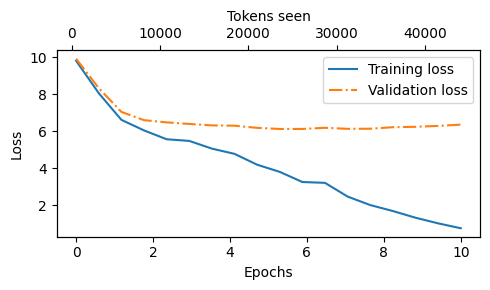

In [73]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 绘制随着训练进行（epoch值增大）训练集损失和验证集损失的变化情况
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # 创建第二个x轴用于显示可观察的tokens
    ax2 = ax1.twiny()  # 创建一个共享相同y轴的第二个x轴
    ax2.plot(tokens_seen, train_losses, alpha=0)  # 用于对齐刻度的不可见图表
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # 调整布局以节省空间
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- 从以上结果可以看出，该模型一开始生成的是难以理解的词串，而到了后期，它能够生成语法基本正确的句子
- 然而，根据训练集和验证集的损失，我们可以看出模型开始过拟合
- 如果我们检查一下它在结尾处写的几段文字，就会发现它们与训练集中的内容完全一致——它只是简单地记住了训练数据
- 稍后，我们将介绍一些解码策略，这些策略可以在一定程度上减轻这种记忆的影响
- 请注意，这里出现过拟合是因为我们的训练集非常非常小，而我们却对其进行了多次迭代
  - 此处的LLM训练主要用于教学目的；我们主要想验证该模型能否学习生成连贯的文本
  - 我们无需花费数周甚至数月的时间在大量昂贵的硬件上训练这个模型，而是稍后加载预训练权重

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/13.webp" width=900px>

**如果您有兴趣使用更高级的技术（例如学习率预热、余弦退火和梯度裁剪）来增强此训练功能，请参阅 [Appendix D](../../appendix-D/01_main-chapter-code)**

**如果您对更大的训练数据集和更长的训练周期感兴趣，请参阅 [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)**

## 5.3 控制随机性的解码策略

- 使用相对较小的大型语言模型（如我们上面训练的GPT模型），推理过程相对廉价，因此如果您在上面使用GPU进行了训练，那么在推理时就不需要使用GPU。
- 使用我们之前在简单训练函数中使用的generate_text_simple函数（来自上一章），我们可以一次生成一个单词（或token）的新文本。
- 如5.1.2节所解释的，下一个生成的token是词汇表中所有标记中对应最大概率分数的token。

In [82]:
# NEW: 此处使用 CPU 是因为该模型的推理成本很低，而且为了确保读者在本书的其余章节中获得相同的结果，请谨慎使用
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




- 即使我们多次执行上面的generate_text_simple函数，大型语言模型（LLM）始终会生成相同的输出。
- 现在我们引入两个概念，所谓的解码策略，来修改generate_text_simple：温度缩放和top-k采样。
- 这将允许模型控制生成文本的随机性和多样性。

### 5.3.1 温度缩放

- 之前，我们总是使用torch.argmax采样最大概率的标记作为下一个标记。
- 为了增加多样性，我们可以使用torch.multinomial(probs, num_samples=1)从概率分布中采样下一个标记。
- 在这里，每个索引被选中的机会与其在输入张量中的概率相对应。

In [83]:
# 以下简要回顾一下生成下一个词元的过程，为了便于说明，假设词汇量非常小

vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# 假设input是 "every effort moves you", 模型返回的logits值为下面tensor中的数值::
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

# 生成的下一个token:
print(inverse_vocab[next_token_id])

forward


In [84]:
# 我们不通过 torch.argmax 来确定最可能的标记，而是使用 torch.multinomial(probas, num_samples=1) 通过从 softmax 分布中采样来确定最可能的标记
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [85]:
# multinomial函数按照其概率分数采样下一个词元。换句话说，forward仍然是最可能的词元，大多数时间（但不是每次）都会被multinomial选中
# 为了便于说明，我们来看看使用原始softmax概率对下一个标记进行1000次采样会发生什么:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


- 我们可以通过一个称为温度缩放的概念来控制分布和选择过程。
- “温度缩放”只是将logits除以一个大于0的数字的高级说法。
- 大于1的温度值将在应用softmax后导致更均匀分布的标记概率。
- 小于1的温度值将在应用softmax后导致更自信（更尖锐或更高峰）的分布。

- 请注意，根据操作系统不同，最终的输出结果可能有所不同；您可以阅读更多关于这种不一致性的信息 [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

In [86]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# 温度值
temperatures = [1, 0.1, 5]  # 原始值、较高置信度和较低置信度

# 计算缩放概率
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

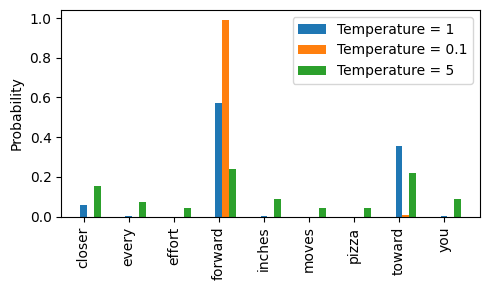

In [87]:
# 绘制
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- 我们可以看到，通过温度 0.1 进行重新缩放，可以得到更集中的分布，接近 torch.argmax，使得最有可能的词几乎总是被选中:

In [35]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


- 通过温度 5 重新标度后的概率分布更加均匀:

In [36]:
print_sampled_tokens(scaled_probas[2])

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


- 假设 LLM 输入“every effort moves you”，使用上述方法有时会产生无意义的文本，例如“every effort moves you pizza”，这种情况发生的概率为 3.2%（1000 次中有 32 次）

### 5.3.2 Top-k 采样

- 为了能够利用更高的温度来增加输出多样性并降低无意义句子的概率，我们可以将采样标记限制为最有可能的前 k 个标记:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/15.webp" width=900px>

> 请注意，为了减少视觉混乱，图中数字已截断至小数点后两位。Softmax 行中的值之和应为 1.0

In [37]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [38]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


> 注意:  
>
> 前述代码单元的另一种实现方式，效率略高，如下所示:
>
> ```python
> new_logits = torch.full_like( # create tensor containing -inf values
>    next_token_logits, -torch.inf
>)   
> new_logits[top_pos] = next_token_logits[top_pos] # copy top k values into the -inf tensor
> ```
> <br>
> 更多详情请参见 https://github.com/rasbt/LLMs-from-scratch/discussions/326


In [39]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 修改文本生成功能

- 前两小节介绍了温度采样和top-k采样。
- 让我们运用这两个概念来修改第 4 章中的 `generate_text_simple` 函数，创建一个新的 `generate` 函数

In [88]:
# 运用温度采样和top-k采样，将第四章的`generate_text_simple`函数升级为`generate`
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # or 循环与之前相同：获取 logits，并且只关注最后一个时间步
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: 使用 top_k 采样对 logits 进行过滤
        if top_k is not None:
            # 仅保留前 k 个值
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: 应用温度缩放
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): 数值稳定性技巧：为了在 MPS 设备上获得等效结果，请在 softmax 之前减去逐行最大值。
            logits = logits - logits.max(dim=-1, keepdim=True).values
            
            # 应用 softmax 函数得到概率
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # 从分布中抽样
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # 否则，操作与之前相同：获取具有最高 logits 值的词汇表条目的索引
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # 如果遇到序列结束标记且指定了 eos_id，则提前停止生成
            break

        # 与之前相同：将采样索引追加到运行序列中
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [89]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves youlit," she up surprise. And. Gisburn! by his last


## 5.4 在 PyTorch 中加载和保存模型权重

- 训练 LLM 模型计算量很大，因此能够保存和加载 LLM 权重至关重要
- 
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/16.webp" width=900px>

- The recommended way in PyTorch is to save the model weights, the so-called `state_dict` via by applying the `torch.save` function to the `.state_dict()` method:

In [42]:
torch.save(model.state_dict(), "model.pth")

In [43]:
# 然后我们可以按如下方式将模型权重加载到新的 `GPTModel` 模型实例中
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

In [90]:
# 通常使用自适应优化器（例如 Adam 或 AdamW）而不是常规的随机梯度下降法 (SGD) 来训练 LLM
# 这些自适应优化器会为每个模型权重存储额外的参数，因此，如果我们计划稍后继续进行预训练，也应该保存这些参数:

# 保存
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

In [91]:
# 加载
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

## 5.5 从 OpenAI 加载预训练权重

- 之前，我们仅出于教育目的，使用一本篇幅很短的短篇小说集训练了一个小型 GPT-2 模型
- 感兴趣的读者还可以找到基于完整古腾堡计划书籍语料库的更长预训练运行结果 [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)
- 幸运的是，我们不必花费数万甚至数十万美元在大型预训练语料库上预训练模型，而是可以加载 OpenAI 提供的预训练权重

⚠️ **注意：由于 TensorFlow 兼容性问题，部分用户可能会在本节中遇到问题，尤其是在某些 Windows 系统上。此处仅需 TensorFlow 来加载原始的 OpenAI GPT-2 权重文件，然后将其转换为 PyTorch 格式。   
如果您遇到与 TensorFlow 相关的问题，可以使用下面的替代代码代替本节中的其余代码。   
此替代方案基于预先转换的 PyTorch 权重，这些权重是使用与上一节所述相同的转换过程创建的。有关详细信息，请参阅 notebook:
[../02_alternative_weight_loading/weight-loading-pytorch.ipynb](../02_alternative_weight_loading/weight-loading-pytorch.ipynb) notebook.**

```python
file_name = "gpt2-small-124M.pth"
# file_name = "gpt2-medium-355M.pth"
# file_name = "gpt2-large-774M.pth"
# file_name = "gpt2-xl-1558M.pth"

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)
    print(f"Downloaded to {file_name}")

gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=True))
gpt.eval()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")
gpt.to(device);


torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))
```

- 首先，一些样板代码用于从 OpenAI 下载文件并将权重加载到 Python 中
- 由于 OpenAI 使用 [TensorFlow](https://www.tensorflow.org/), 我们需要安装并使用TensorFlow来加载权重; [tqdm](https://github.com/tqdm/tqdm) 是一个进度条库
- 取消注释并运行下一个单元格以安装所需的库

In [93]:
pip install tensorflow tqdm

Looking in indexes: http://mirrors.cloud.aliyuncs.com/pypi/simple/
Note: you may need to restart the kernel to use updated packages.


In [94]:
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.20.0
tqdm version: 4.67.3


In [95]:
# 从此文件夹中的 gpt_download.py 文件进行相对导入
from gpt_download import download_and_load_gpt2
# 或者:
# from llms_from_scratch.ch05 import download_and_load_gpt2

2026-03-06 17:17:24.198691: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


---

**注意**

- 极少数情况下，上述代码单元格可能会导致 `zsh: illegal hardware instruction python` 错误，这可能是由于您机器上的 TensorFlow 安装存在问题所致
- 一位读者发现，通过 `conda` 安装 TensorFlow 可以解决此特定案例中的问题，正如前面提到的 [here](https://github.com/rasbt/LLMs-from-scratch/discussions/273#discussioncomment-12367888)
- 您可以在本补充材料中找到更多说明 [Python setup tutorial](https://github.com/rasbt/LLMs-from-scratch/tree/main/setup/01_optional-python-setup-preferences#option-2-using-conda)

---

In [97]:
# 我们可以按如下方式下载包含 1.24 亿个参数的模型的模型权重
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [101]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [102]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [119]:
print(params["wte"])
print("词嵌入权重张量维度:", params["wte"].shape)
print("wpe是pos_emb", params['wpe'].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
词嵌入权重张量维度: (50257, 768)
(1024, 768)


- 此外，还支持“355M”、“774M”和“1558M”这几个 `model_size` 参数
- 下图总结了这些不同尺寸模型之间的差异:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/17.webp" width=900px>

- 上面我们已经将 1.24 亿个 GPT-2 模型权重加载到 Python 中，但是我们仍然需要将它们转换到我们的 `GPTModel` 实例中
- 首先，我们初始化一个新的 GPTModel 实例
- 请注意，原始的GPT模型在多头注意力模块的查询、键和值矩阵的线性层中使用了带偏置向量的初始化，这是不必要的，也不推荐；然而，为了能够正确加载权重，我们也必须在我们的实现中通过设置qkv_bias为True来启用这些。
- 我们还使用了原始 GPT-2 模型所使用的 `1024` 标记上下文长度

In [120]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

- 下一步是将 OpenAI 权重分配给 GPTModel 实例中相应的权重张量

In [121]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [122]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)
gpt.to(device);

- 如果模型加载正确，我们可以使用之前的生成函数来生成新的文本

In [125]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something interrupts your control flow. As you may observe I


- 我们知道模型权重加载正确，因为模型能够生成连贯的文本；因为假如我们犯了一个很小的错误，模型也无法做到这一点。

- 如需了解从 Hugging Face Hub 加载配重的另一种方法，请参阅 [../02_alternative_weight_loading](../02_alternative_weight_loading)
- 如果您有兴趣了解 GPT 架构与 Llama 架构（由 Meta AI 开发的流行 LLM）的比较情况，请参阅以下附加内容[../07_gpt_to_llama](../07_gpt_to_llama)

## 总结与要点

- 请参阅 [./gpt_train.py](./gpt_train.py) 脚本，这是一个独立的训练脚本。
- [./gpt_generate.py](./gpt_generate.py) 脚本从 OpenAI 加载预训练权重，并根据提示生成文本。
- 您可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 中找到练习答案。